In [1]:
from Bio import SeqIO
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import pairwise2
from Bio.Seq import  Seq
from Bio.Align import PairwiseAligner

In [5]:
file_path = r'E:\pUGTdb\pUGTdb_completeUGTs.pep'

In [22]:
with open(file_path, 'rb') as f:
    raw_data = f.read()

In [32]:
# 存储序列信息的列表
sequences_data = []
# 解析FASTA文件
for record in SeqIO.parse(file_path, "fasta"):
    sequences_data.append({
        'name': record.description,      # 序列名称
        'sequence': str(record.seq)  # 序列内容
    })
# 创建DataFrame
df = pd.DataFrame(sequences_data)
# 保存为CSV文件
csv_file_path = r'E:\pUGTdb\pUGTdb_completeUGTs.csv'
df.to_csv(csv_file_path, index=False)

print(f"成功转换 {len(sequences_data)} 条序列到CSV格式")
print(f"CSV文件已保存至: {csv_file_path}")


成功转换 228587 条序列到CSV格式
CSV文件已保存至: E:\pUGTdb\pUGTdb_completeUGTs.csv

数据预览:
                                                name  \
0  TXG46902.1 hypothetical protein EZV62_026196 [...   
1  TXG46911.1 hypothetical protein EZV62_026205 [...   
2  TXG47487.1 hypothetical protein EZV62_026781 [...   
3  TXG47488.1 hypothetical protein EZV62_026782 [...   
4  TXG47490.1 hypothetical protein EZV62_026784 [...   

                                            sequence  
0  MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...  
1  MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...  
2  METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...  
3  MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...  
4  MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...  


In [35]:
df

,name,sequence
0,TXG46902.1 hypothetical protein EZV62_026196 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...
1,TXG46911.1 hypothetical protein EZV62_026205 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...
2,TXG47487.1 hypothetical protein EZV62_026781 [...,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...
3,TXG47488.1 hypothetical protein EZV62_026782 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...
4,TXG47490.1 hypothetical protein EZV62_026784 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...
...,...,...
228582,XP_030973956.1 [Quercus lobata],MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...
228583,XP_030975687.1 [Quercus lobata],MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...
228584,XP_024024627.1 [Morus notabilis],MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...
228585,XP_024029391.1 [Morus notabilis],MGSNGDDHHPMKHLDHHPMKHLEESVNHFDQQSGGGGGDNNSGNEQ...


In [39]:
# 物种分布统计
# 从 name 列提取物种信息
def extract_species(name):
    # 匹配 [物种名称] 格式
    match = re.search(r'\[([^\]]+)\]', name)
    return match.group(1) if match else 'Unknown'
df['species'] = df['name'].apply(extract_species)
species_count = df['species'].value_counts()

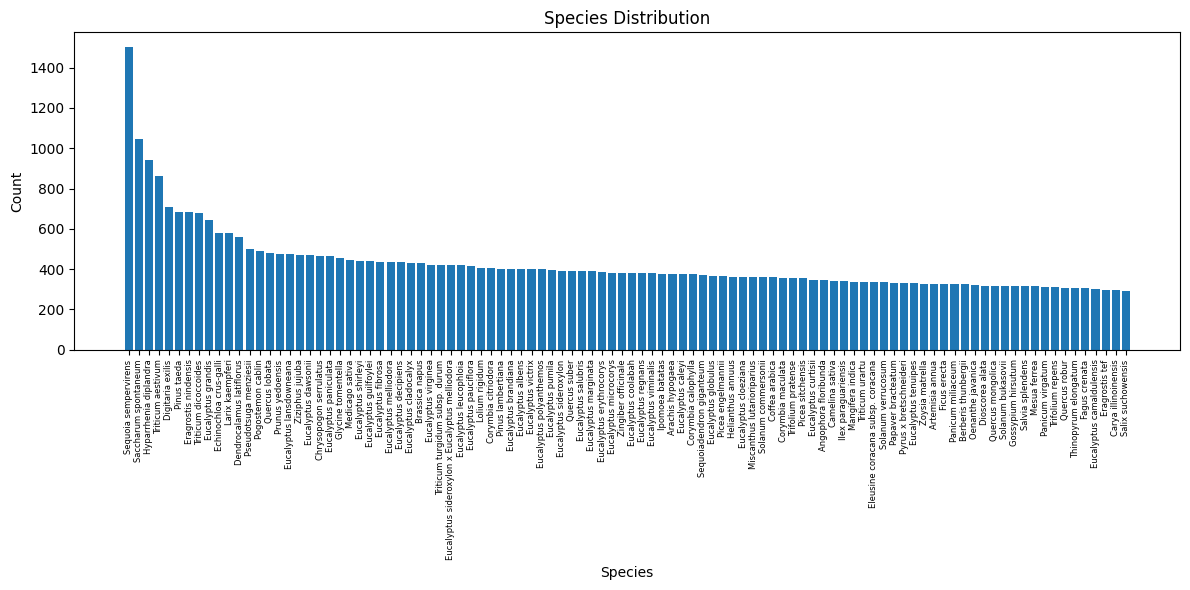

In [52]:
plt.figure(figsize=(12, 6))
species_count_show = species_count.head(100)
plt.bar(species_count_show.index, species_count_show)
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Species Distribution')
plt.xticks(rotation=90)
plt.setp(plt.gca().get_xticklabels(), fontsize=6)  # 使用setp设置x轴标签字体大小
plt.tight_layout()
plt.show()

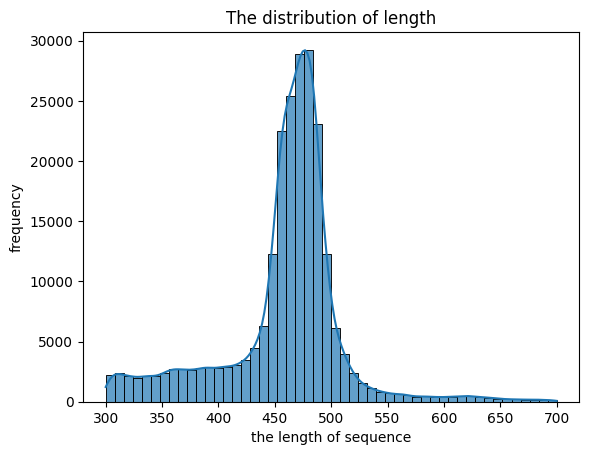

In [81]:
# 序列长度分布
df['sequence_length'] = df['sequence'].str.len()
# 绘制带密度曲线的直方图
sns.histplot(df['sequence_length'], bins=50, kde=True, alpha=0.7)
plt.xlabel("the length of sequence")
plt.ylabel('frequency')
plt.title('The distribution of length')
plt.show()


In [56]:
# 基于描述文本的功能分类
def classify_function(name):
    name_lower = name.lower()
    if 'hypothetical' in name_lower:
        return 'Hypothetical protein'
    elif 'ugt' in name_lower or 'udp' in name_lower:
        return 'UDP-glucuronosyltransferase'
    elif 'protein' in name_lower:
        # 提取 protein 后面的关键词
        match = re.search(r'protein\s+([a-zA-Z0-9_]+)', name_lower)
        if match:
            return f"Protein {match.group(1)}"
    return 'Other'

df['function_category'] = df['name'].apply(classify_function)
function_count = df['function_category'].value_counts()
print("功能分类统计:")
print(function_count.head(10))


功能分类统计:
Other                          211678
UDP-glucuronosyltransferase     11325
Hypothetical protein             4436
Protein product                  1071
Protein of                          7
Protein isoform                     2
Protein loc100382065                1
Protein loc100383745                1
Protein loc100383681                1
Protein loc100383146                1
Name: function_category, dtype: int64


In [67]:
function_count

Other                          211678
UDP-glucuronosyltransferase     11325
Hypothetical protein             4436
Protein product                  1071
Protein of                          7
                                ...  
Protein loc100273251                1
Protein loc100273555                1
Protein loc100273588                1
Protein loc100274286                1
Protein loc105128206                1
Name: function_category, Length: 74, dtype: int64

In [57]:
# ID前缀分析
def extract_id_prefix(name):
    # 提取ID并获取前缀部分
    id_match = re.match(r'^([a-zA-Z]+)', name)
    return id_match.group(1) if id_match else 'Unknown'

df['id_prefix'] = df['name'].apply(extract_id_prefix)
id_prefix_count = df['id_prefix'].value_counts()
print("ID前缀分布:")
print(id_prefix_count)


ID前缀分布:
Unknown          72927
R                37228
XP               22634
A                 6698
KAI               2186
                 ...  
Chlamydomonas        1
MCI                  1
PraiT                1
ShimT                1
CAG                  1
Name: id_prefix, Length: 976, dtype: int64


In [70]:
def clean_sequence_str(seq):
    """移除空白符，转大写，移除末尾的*"""
    if not isinstance(seq, str): return ""
    seq = seq.strip().upper()
    if seq.endswith('*') or seq.endswith('.'):  #因为最后一个*是代表终止密码子，就是翻译完了，并不是错误序列
        seq = seq[:-1]
    return seq

def is_valid_sequence(seq):
    """检查是否只包含 20 种标准氨基酸"""
    standard_aa = set("ACDEFGHIKLMNPQRSTVWY")
    if len(seq) == 0: return False
    return all(char in standard_aa for char in seq)

# Step 1: 基础字符清洗
df['clean_seq'] = df['sequence'].apply(clean_sequence_str)
# Step 2: 剔除含非法字符的序列 (X, B, Z, J, *, 等)
valid_mask = df['clean_seq'].apply(is_valid_sequence)
df_valid_char = df[valid_mask].copy()
# Step 3: 剔除ID的尾缀是T的序列（可能是转录本，置信度低），同时，提出R和A前缀的序列，可能是 PDB 链（Chain A）或者棉花 A 亚基因组；可能是 RefSeq 简写或 Repeat
df_filtered = df_valid_char[~df_valid_char['id_prefix'].str.endswith('T')]
df_filtered = df_filtered[~df_filtered['id_prefix'].isin(['R', 'A'])]  #

In [74]:
df_filtered

,name,sequence,species,sequence_length,function_category,id_prefix,clean_seq
0,TXG46902.1 hypothetical protein EZV62_026196 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,Acer yangbiense,442,Hypothetical protein,TXG,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...
1,TXG46911.1 hypothetical protein EZV62_026205 [...,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...,Acer yangbiense,475,Hypothetical protein,TXG,MGKPHVVCIPYPAQGHIKPMLNVAKLLHSKGFHITFVNTEYNHKRL...
2,TXG47487.1 hypothetical protein EZV62_026781 [...,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...,Acer yangbiense,481,Hypothetical protein,TXG,METKVVASNLRLSKVSCQKKKRVAMGEKKLHIAMYPWLAMSHLNAF...
3,TXG47488.1 hypothetical protein EZV62_026782 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,Acer yangbiense,456,Hypothetical protein,TXG,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...
4,TXG47490.1 hypothetical protein EZV62_026784 [...,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...,Acer yangbiense,456,Hypothetical protein,TXG,MEEKSLHIAMYPWFAMSHLNAFLQLSNKLAERGHRVSFLLPEKTQA...
...,...,...,...,...,...,...,...
228582,XP_030973956.1 [Quercus lobata],MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...,Quercus lobata,394,Other,XP,MLKHQQNQFVIVTYPLQGHINPAFQFAERLIRLGVHVTFFTAIGAH...
228583,XP_030975687.1 [Quercus lobata],MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...,Quercus lobata,457,Other,XP,MDSKQERSNSISILMLPWLAHGHISPFLDLARKLSLRNFHVYFCST...
228584,XP_024024627.1 [Morus notabilis],MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...,Morus notabilis,461,Other,XP,MEEIRREKGTHILVIPYPVQGHINPMLQFSKRLASKNRRLIRITLL...
228585,XP_024029391.1 [Morus notabilis],MGSNGDDHHPMKHLDHHPMKHLEESVNHFDQQSGGGGGDNNSGNEQ...,Morus notabilis,635,Other,XP,MGSNGDDHHPMKHLDHHPMKHLEESVNHFDQQSGGGGGDNNSGNEQ...


In [83]:
ugt_df = df_filtered[df_filtered['function_category'] == 'UDP-glucuronosyltransferase']

In [87]:
ugt_df['name'].tolist()

['GAQ77601.1 UDP-Glycosyltransferase superfamily protein [Klebsormidium nitens]',
 'GAQ90052.1 UDP-Glycosyltransferase superfamily protein [Klebsormidium nitens]',
 'GAQ90247.1 UDP-glucosyl transferase [Klebsormidium nitens]',
 'QDZ21230.1 UDP-glucuronosyl/UDP-glucosyltransferase [Chloropicon primus]',
 'XP_030512789.1 UDP-glycosyltransferase 13-like [Rhodamnia argentea]',
 'XP_030512791.1 UDP-glycosyltransferase 13-like [Rhodamnia argentea]',
 'XP_030512800.1 UDP-glycosyltransferase 13-like [Rhodamnia argentea]',
 'XP_030513369.1 UDP-glycosyltransferase 72E3-like [Rhodamnia argentea]',
 'XP_030514542.1 UDP-glycosyltransferase 72E1-like [Rhodamnia argentea]',
 'XP_030519456.1 UDP-glycosyltransferase 83A1-like [Rhodamnia argentea]',
 'XP_030519499.1 UDP-glycosyltransferase 83A1-like [Rhodamnia argentea]',
 'XP_030520932.1 UDP-glucosyltransferase 29-like [Rhodamnia argentea]',
 'XP_030521482.1 UDP-glycosyltransferase 83A1-like [Rhodamnia argentea]',
 'XP_030521483.1 UDP-glycosyltransfera

In [92]:
# 实现序列的MSA
all_seq = {
    'Q6VAB4':'MENKTETTVRRRRRIILFPVPFQGHINPILQLANVLYSKGFSITIFHTNFNKPKTSNYPHFTFRFILDNDPQDERISNLPTHGPLAGMRIPIINEHGADELRRELELLMLASEEDEEVSCLITDALWYFAQSVADSLNLRRLVLMTSSLFNFHAHVSLPQFDELGYLDPDDKTRLEEQASGFPMLKVKDIKSAYSNWQILKEILGKMIKQTKASSGVIWNSFKELEESELETVIREIPAPSFLIPLPKHLTASSSSLLDHDRTVFQWLDQQPPSSVLYVSFGSTSEVDEKDFLEIARGLVDSKQSFLWVVRPGFVKGSTWVEPLPDGFLGERGRIVKWVPQQEVLAHGAIGAFWTHSGWNSTLESVCEGVPMIFSDFGLDQPLNARYMSDVLKVGVYLENGWERGEIANAIRRVMVDEEGEYIRQNARVLKQKADVSLMKGGSSYESLESLVSYISSL',
    'Q6VAA6':'MAEQQKIKKSPHVLLIPFPLQGHINPFIQFGKRLISKGVKTTLVTTIHTLNSTLNHSNTTTTSIEIQAISDGCDEGGFMSAGESYLETFKQVGSKSLADLIKKLQSEGTTIDAIIYDSMTEWVLDVAIEFGIDGGSFFTQACVVNSLYYHVHKGLISLPLGETVSVPGFPVLQRWETPLILQNHEQIQSPWSQMLFGQFANIDQARWVFTNSFYKLEEEVIEWTRKIWNLKVIGPTLPSMYLDKRLDDDKDNGFNLYKANHHECMNWLDDKPKESVVYVAFGSLVKHGPEQVEEITRALIDSDVNFLWVIKHKEEGKLPENLSEVIKTGKGLIVAWCKQLDVLAHESVGCFVTHCGFNSTLEAISLGVPVVAMPQFSDQTTNAKLLDEILGVGVRVKADENGIVRRGNLASCIKMIMEEERGVIIRKNAVKWKDLAKVAVHEGGSSDNDIVEFVSELIKA',
    'B3VI56':'MATSDSIVDDRKQLHVATFPWLAFGHILPYLQLSKLIAEKGHKVSFLSTTRNIQRLSSHISPLINVVQLTLPRVQELPEDAEATTDVHPEDIPYLKKASDGLQPEVTRFLEQHSPDWIIYDYTHYWLPSIAASLGISRAHFSVTTPWAIAYMGPSADAMINGSDGRTTVEDLTTPPKWFPFPTKVCWRKHDLARLVPYKAPGISDGYRMGLVLKGSDCLLSKCYHEFGTQWLPLLETLHQVPVVPVGLLPPEVPGDEKDETWVSIKKWLDGKQKGSVVYVALGSEVLVSQTEVVELALGLELSGLPFVWAYRKPKGPAKSDSVELPDGFVERTRDRGLVWTSWAPQLRILSHESVCGFLTHCGSGSIVEGLMFGHPLIMLPIFGDQPLNARLLEDKQVGIEIPRNEEDGCLTKESVARSLRSVVVEKEGEIYKANARELSKIYNDTKVEKEYVSQFVDYLEKNTRAVAIDHES',
    'Q6VAB0':'MDAMATTEKKPHVIFIPFPAQSHIKAMLKLAQLLHHKGLQITFVNTDFIHNQFLESSGPHCLDGAPGFRFETIPDGVSHSPEASIPIRESLLRSIETNFLDRFIDLVTKLPDPPTCIISDGFLSVFTIDAAKKLGIPVMMYWTLAACGFMGFYHIHSLIEKGFAPLKDASYLTNGYLDTVIDWVPGMEGIRLKDFPLDWSTDLNDKVLMFTTEAPQRSHKVSHHIFHTFDELEPSIIKTLSLRYNHIYTIGPLQLLLDQIPEEKKQTGITSLHGYSLVKEEPECFQWLQSKEPNSVVYVNFGSTTVMSLEDMTEFGWGLANSNHYFLWIIRSNLVIGENAVLPPELEEHIKKRGFIASWCSQEKVLKHPSVGGFLTHCGWGSTIESLSAGVPMICWPYSWDQLTNCRYICKEWEVGLEMGTKVKRDEVKRLVQELMGEGGHKMRNKAKDWKEKARIAIAPNGSSSLNIDKMVKEITVLARN',
    'Q6VAA8':'MYNVTYHQNSKAMATSDSIVDDRKQLHVATFPWLAFGHILPFLQLSKLIAEKGHKVSFLSTTRNIQRLSSHISPLINVVQLTLPRVQELPEDAEATTDVHPEDIQYLKKAVDGLQPEVTRFLEQHSPDWIIYDFTHYWLPSIAASLGISRAYFCVITPWTIAYLAPSSDAMINDSDGRTTVEDLTTPPKWFPFPTKVCWRKHDLARMEPYEAPGISDGYRMGMVFKGSDCLLFKCYHEFGTQWLPLLETLHQVPVVPVGLLPPEIPGDEKDETWVSIKKWLDGKQKGSVVYVALGSEALVSQTEVVELALGLELSGLPFVWAYRKPKGPAKSDSVELPDGFVERTRDRGLVWTSWAPQLRILSHESVCGFLTHCGSGSIVEGLMFGHPLIMLPIFCDQPLNARLLEDKQVGIEIPRNEEDGCLTKESVARSLRSVVVENEGEIYKANARALSKIYNDTKVEKEYVSQFVDYLEKNARAVAIDHES',
    'Q6VAA9':'MSPKMVAPPTNLHFVLFPLMAQGHLVPMVDIARILAQRGATVTIITTPYHANRVRPVISRAIATNLKIQLLELQLRSTEAGLPEGCESFDQLPSFEYWKNISTAIDLLQQPAEDLLRELSPPPDCIISDFLFPWTTDVARRLNIPRLVFNGPGCFYLLCIHVAITSNILGENEPVSSNTERVVLPGLPDRIEVTKLQIVGSSRPANVDEMGSWLRAVEAEKASFGIVVNTFEELEPEYVEEYKTVKDKKMWCIGPVSLCNKTGPDLAERGNKAAITEHNCLKWLDERKLGSVLYVCLGSLARISAAQAIELGLGLESINRPFIWCVRNETDELKTWFLDGFEERVRDRGLIVHGWAPQVLILSHPTIGGFLTHCGWNSTIESITAGVPMITWPFFADQFLNEAFIVEVLKIGVRIGVERACLFGEEDKVGVLVKKEDVKKAVECLMDEDEDGDQRRKRVIELAKMAKIAMAEGGSSYENVSSLIRDVTETVRAPH',
    'Q6VAA4':'MDQMAKIDEKKPHVVFIPFPAQSHIKCMLKLARILHQKGLYITFINTDTNHERLVASGGTQWLENAPGFWFKTVPDGFGSAKDDGVKPTDALRELMDYLKTNFFDLFLDLVLKLEVPATCIICDGCMTFANTIRAAEKLNIPVILFWTMAACGFMAFYQAKVLKEKEIVPVKDETYLTNGYLDMEIDWIPGMKRIRLRDLPEFILATKQNYFAFEFLFETAQLADKVSHMIIHTFEELEASLVSEIKSIFPNVYTIGPLQLLLNKITQKETNNDSYSLWKEEPECVEWLNSKEPNSVVYVNFGSLAVMSLQDLVEFGWGLVNSNHYFLWIIRANLIDGKPAVMPQELKEAMNEKGFVGSWCSQEEVLNHPAVGGFLTHCGWGSIIESLSAGVPMLGWPSIGDQRANCRQMCKEWEVGMEIGKNVKRDEVEKLVRMLMEGLEGERMRKKALEWKKSATLATCCNGSSSLDVEKLANEIKKLSRN',
    'Q6VAB2':'MSTSELVFIPSPGAGHLPPTVELAKLLLHRDQRLSVTIIVMNLWLGPKHNTEARPCVPSLRFVDIPCDESTMALISPNTFISAFVEHHKPRVRDIVRGIIESDSVRLAGFVLDMFCMPMSDVANEFGVPSYNYFTSGAATLGLMFHLQWKRDHEGYDATELKNSDTELSVPSYVNPVPAKVLPEVVLDKEGGSKMFLDLAERIRESKGIIVNSCQAIERHALEYLSSNNNGIPPVFPVGPILNLENKKDDAKTDEIMRWLNEQPESSVVFLCFGSMGSFNEKQVKEIAVAIERSGHRFLWSLRRPTPKEKIEFPKEYENLEEVLPEGFLKRTSSIGKVIGWAPQMAVLSHPSVGGFVSHCGWNSTLESMWCGVPMAAWPLYAEQTLNAFLLVVELGLAAEIRMDYRTDTKAGYDGGMEVTVEEIEDGIRKLMSDGEIRNKVKDVKEKSRAAVVEGGSSYASIGKFIEHVSNVTI',
    'Q6VAB3':'MASIAEMQKPHAICIPYPAQGHINPMMQFAKLLHFKGFHISFVNNHYNHKRLQRSRGLSALEGLPDFHFYSIPDGLPPSNAEATQSIPGLCESIPKHSLEPFCDLIATLNGSDVPPVSCIISDGVMSFTLQAAERFGLPEVLFWTPSACGFLAYTHYRDLVDKEYIPLKDTNDLTNGYLETSLDWIPGMKNIRLKDFPSFIRTTDINDIMLNYFLIETEAIPKGVAIILNTFDALEKDSITPVLALNPQIYTIGPLHMMQQYVDHDERLKHIGSNLWKEDVSCINWLDTKKPNSVVYVNFGSITVMTKEQLIEFGWGLANSKKDFLWITRPDIVGGNEAMIPAEFIEETKERGMVTSWCSQEEVLKHPSIGVFLTHSGWNSTIESISNGVPMICWPFFAEQQTNCRYCCVEWEIGLEIDTDVKREEVEAQVREMMDGSKGKMMKNKALEWKKKAEEAVSIGGSSYLNFEKLVTDVLLRK'
}

In [94]:
aligner = PairwiseAligner()
aligner.mode = 'global'

In [95]:
target_seq = all_seq["Q6VAB4"]

In [96]:
def calculate_identity(seq):
    score = aligner.score(target_seq, seq)
    return (score / max(len(target_seq), len(seq))) * 100

for seq_name, seq, in all_seq.items():
    print(f"{seq_name}:{calculate_identity(seq)}")